# Atividade — Perfis de estudantes com K-Means

Descobrir perfis de rotina e desempenho acadêmico sem informar os perfis ao algoritmo.

**Arquivo de dados:** `estudantes_kmeans.csv`

> Regra central: as colunas de referência servem somente para avaliar o resultado no final. Elas não podem entrar em `X`.

## 1. Importe as bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score

SEMENTE = 42

## 2. Carregue e inspecione os dados

Use `pd.read_csv`, `head`, `shape`, `info`, `describe` e `isna().sum()`.

In [2]:
# TODO: carregue estudantes_kmeans.csv
df = pd.read_csv("estudantes_kmeans.csv")
display(df.head())
print("Dimensoes:", df.shape)
display(df.describe(include="all"))
print("Ausentes por coluna:\n", df.isna().sum())

,estudante_id,horas_estudo_semana,frequencia_pct,media_notas,horas_sono,faltas_semestre,perfil_referencia
0,EST001,4.5,70.4,4.3,6.7,10,precisa_apoio
1,EST002,4.8,59.9,5.7,5.5,14,precisa_apoio
2,EST003,4.5,71.9,4.8,5.9,11,precisa_apoio
3,EST004,4.4,58.3,4.5,6.1,11,precisa_apoio
4,EST005,7.6,63.7,4.0,5.9,14,precisa_apoio


Dimensoes: (90, 7)


,estudante_id,horas_estudo_semana,frequencia_pct,media_notas,horas_sono,faltas_semestre,perfil_referencia
count,90,90.000000,90.000000,90.000000,90.000000,90.000000,90
unique,90,NaN,NaN,NaN,NaN,NaN,3
top,EST001,NaN,NaN,NaN,NaN,NaN,precisa_apoio
freq,1,NaN,NaN,NaN,NaN,NaN,30
mean,NaN,10.048889,82.194444,6.962222,6.925556,6.488889,NaN
std,NaN,4.909112,13.434823,1.758420,0.974225,4.983669,NaN
min,NaN,2.900000,50.600000,3.700000,4.400000,0.000000,NaN
25%,NaN,6.000000,74.125000,5.625000,6.100000,2.000000,NaN
50%,NaN,9.000000,84.100000,7.050000,7.000000,5.000000,NaN
75%,NaN,14.775000,95.125000,8.575000,7.675000,11.000000,NaN


Ausentes por coluna:
 estudante_id           0
horas_estudo_semana    0
frequencia_pct         0
media_notas            0
horas_sono             0
faltas_semestre        0
perfil_referencia      0
dtype: int64


## 3. Prepare X e padronize

Remova `estudante_id` e `perfil_referencia`. Use somente as cinco variáveis numéricas e aplique `StandardScaler`.

In [3]:
# TODO: informe as colunas numericas
colunas = ["horas_estudo_semana", "frequencia_pct", "media_notas", "horas_sono", "faltas_semestre"]
X = df[colunas]
scaler = StandardScaler()
X_padronizado = scaler.fit_transform(X)

## 4. Escolha K

Teste K de 2 a 6. Calcule a inércia e o índice de silhueta e produza dois gráficos.

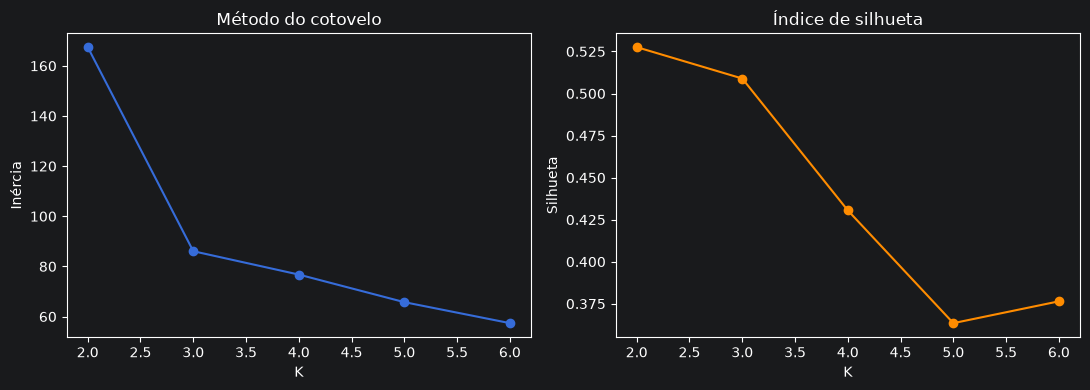

In [4]:
# TODO: complete o teste de K
valores_k = range(2, 7)
inercias, silhuetas = [], []
for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=SEMENTE, n_init=10)
    grupos = modelo.fit_predict(X_padronizado)
    inercias.append(modelo.inertia_)
    silhuetas.append(silhouette_score(X_padronizado, grupos))

# TODO: desenhe os dois graficos
fig, eixos = plt.subplots(1, 2, figsize=(11, 4))
eixos[0].plot(list(valores_k), inercias, marker="o")
eixos[0].set(title="Método do cotovelo", xlabel="K", ylabel="Inércia")
eixos[1].plot(list(valores_k), silhuetas, marker="o", color="darkorange")
eixos[1].set(title="Índice de silhueta", xlabel="K", ylabel="Silhueta")
plt.tight_layout()
plt.show()

## 5. Treine o modelo final

Use K=3, acrescente a coluna `cluster`, mostre as médias por grupo e faça uma visualização com PCA.

,horas_estudo_semana,frequencia_pct,media_notas,horas_sono,faltas_semestre
cluster,,,,,
0,9.12,84.35,6.94,6.98,5.23
1,16.05,95.45,8.98,7.85,1.60
2,4.98,66.78,4.97,5.94,12.63


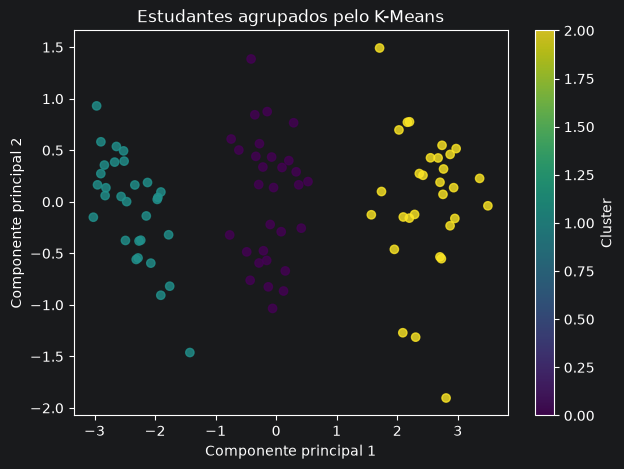

In [5]:
# TODO: ajuste o modelo final
kmeans = KMeans(n_clusters=3, random_state=SEMENTE, n_init=10)
clusters = kmeans.fit_predict(X_padronizado)
df["cluster"] = clusters
resumo = df.groupby("cluster")[colunas].mean().round(2)
display(resumo)

# TODO: reduza para duas dimensoes com PCA e desenhe o grafico
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_padronizado)
plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap="viridis", alpha=0.8)
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Estudantes agrupados pelo K-Means")
plt.colorbar(label="Cluster")
plt.show()

## 6. Avaliação do agrupamento

Somente depois do treinamento, compare os clusters com a coluna de referência usando tabela cruzada e ARI.

In [6]:
# TODO: complete a avaliacao
tabela = pd.crosstab(df["perfil_referencia"], df["cluster"], rownames=["referencia"], colnames=["cluster"])

# TODO: calcule o ARI
ari = adjusted_rand_score(df["perfil_referencia"], clusters)
display(tabela)
print(f"ARI: {ari:.4f}")

cluster,0,1,2
referencia,,,
alto_desempenho,0,30,0
precisa_apoio,0,0,30
regular,30,0,0


ARI: 1.0000
